# Test ABL with K-epsilon model

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# Set up mesh and BL parameters
Uinf = 1.0
nu   = 1.5E-5 # m^2/s

# y-z mesh 
#zmin = 1
#zmax = 120
#Nz   = int((zmax-zmin)/1.0+1)
zmin = 5
zmax = 200
Nz   = int((zmax-zmin)/5.0+1)
zvec = np.linspace(zmin,zmax,Nz)

Ny=51
ymax = 125
yvec = np.linspace(-ymax,ymax,Ny)

# x grid
xvecplot = [0, 10]

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')

dy = 5.0
dz = 5.0


In [5]:
# Set ABL parameters
ABLparam = {
    'ustar' : 0.4, #0.575652,
    'L' : float('inf'),
    'kappa' : 0.42,
    'rho' : 1.225,
    'z0' : 0.15,
    'Cmu' : 5.48**(-2),
}

# This parameter defines V(z) -- m/s per meter
veerpermeter = 0.02 #0.02

In [6]:
def tanhwake(y, z, zhh, turbR, delta, U1, U0=0):
    r = np.sqrt(y**2 + (z-zhh)**2)
    Ur = 0.5*(U1-U0)*(1.0 + np.tanh((r-turbR)/delta)) + U0
    return -Ur

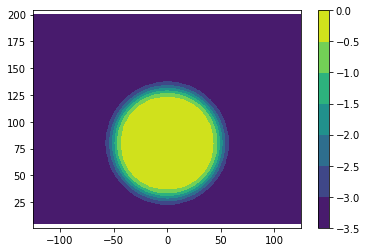

In [7]:
turbhh = 80
turbR  = 50
wakedef= 3.5
rdelta = 7.5 #10.0
wakeU  = wakedef*np.exp(-2.0*(ym**2 + (zm-turbhh)**2)/turbR**2)
wakeUr = tanhwake(ym, zm, turbhh, turbR, rdelta, wakedef)
plt.contourf(ym, zm, wakeUr)
plt.axis('equal')
plt.colorbar()

In [8]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,ABLparam)
    
# Set up veer profile
veerV = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerV[i] = veerpermeter*(z-turbhh)
    
# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, UABL), np.interp(zbot, zvec, UABL)
Vtop, Vbot = np.interp(ztop, zvec, veerV), np.interp(zbot, zvec, veerV)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi
print('rotor veer = ',Wdirtop-Wdirbot)

rotor veer =  20.03237818574312


In [9]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
EPSinit= np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = veerV[iz]
    Winit[:, iz] = 0.0
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)*0.05 #0.2
    EPSinit[:, iz] = 9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    
Uinit = Uinit - wakeUr
#for iy, y in enumerate(yvec):
#    Kinit[iy,:]   = SANDwake3D.set_k_init(zvec, dz, Uinit[0,:],ABLparam,k_factor=0.1)
#    EPSinit[iy,:] = SANDwake3D.set_e_init(zvec, dz, Uinit[0,:], Kinit[0,:], ABLparam)
#Kinit[:,0] = Kinit[:,1]
#Kinit[:,-2] = Kinit[:,-1]
#EPSinit[:,0] = EPSinit[:,1]
#EPSinit[:,-2] = EPSinit[:,-1]

phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['eps'] = EPSinit

(0.0, 200.0)

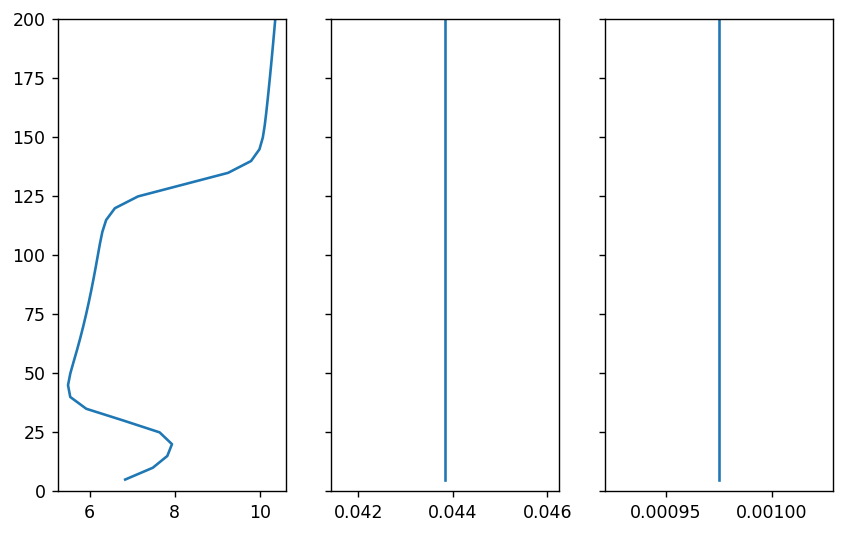

In [10]:
fig, axs = plt.subplots(1,3, sharey=True, dpi=125, figsize=(8,5))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Kinit[Ny//2,:], zvec)
axs[2].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [11]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'neumann', 'value':0.0}
ubc['yhi'] = {'type':'neumann', 'value':0.0}
ubc['zlo'] = {'type':'dirichlet', 'value':Uinit[0,0]}
ubc['zhi'] = {'type':'dirichlet', 'value':Uinit[0,-1]}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':veerV}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'neumann', 'value':0.0}
wbc['yhi'] = {'type':'neumann', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'neumann', 'value':0.0}

kbc = {}
kbc['ylo'] = {'type':'neumann', 'value':0.0}
kbc['yhi'] = {'type':'neumann', 'value':0.0}
kbc['zlo'] = {'type':'dirichlet', 'value':Kinit[0,0]}
kbc['zhi'] = {'type':'neumann', 'value':0.0}

epsbc = {}
epsbc['ylo'] = {'type':'neumann', 'value':0.0}
epsbc['yhi'] = {'type':'neumann', 'value':0.0}
epsbc['zlo'] = {'type':'dirichlet', 'value':EPSinit[0,0]}
epsbc['zhi'] = {'type':'neumann', 'value':0.0}

allbc = {'u':ubc, 'v':vbc, 'w':wbc, 'k':kbc, 'eps':epsbc}

In [12]:
# Set parameters
params = {
    'nu' : nu,
    'Cmu' : 5.48**(-2),
    #'Cmu'  : 0.01,
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
}
#params['nu']       = nu
#params['Cmu']      = 0.0
#params['C1eps']    = 0.0
#params['C2eps']    = 0.0
#params['C3eps']    = 0.0
#params['sigmak']   = 1.0
#params['sigmaeps'] = 1.0

In [13]:
xvecplot=[0, 200, 300, 400] #[0, 100]#[0, 100, 200, 300]
dx  = 20 #25
#firstxvec = [xvecplot[0], xvecplot[0]+5, xvecplot[0]+10]
#xvec = np.concatenate((firstxvec, np.arange(firstxvec[-1]+dx, xvecplot[-1]+1.0E-6, dx)))

#xvec = [0, 10, 20, 30, 40]
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = [0, 10, 20]

#xvec = [0.0, 2.5, 5.0, 7.5, 10, 15, 20, 25, 30]
#xvec = np.arange(xvecplot[0], xvecplot[0]+dx+1.0E-6, dx)

#xvec = xvecplot
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.keps_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=100, tol=1.0E-4)

x = 20.0 dx = 20.0
0 {'u': 2.3648916148003782, 'w': 0.0, 'k': 0.0980215022842838, 'eps': 9.35937172161021e-18, 'v': 0.0}
1 {'u': 0.03263097042656716, 'w': 0.0, 'k': 0.007833625860425894, 'eps': 1.3082057274611545e-17, 'v': 3.5552926712725843}
2 {'u': 0.27698230673137364, 'w': 0.0, 'k': 0.0011372602570444566, 'eps': 1.2713397391652026e-17, 'v': 0.11518510023023731}
3 {'u': 0.007867326671399347, 'w': 0.0, 'k': 0.0009142224593296818, 'eps': 1.2630838978215218e-17, 'v': 0.45507200236340434}
4 {'u': 0.030976365988791783, 'w': 0.0, 'k': 0.0001432952479630538, 'eps': 1.2245246399762276e-17, 'v': 0.010497494023743208}
5 {'u': 0.0009666751772328747, 'w': 0.0, 'k': 8.568894422700265e-05, 'eps': 1.104343872613111e-17, 'v': 0.04283765128845167}
6 {'u': 0.0027304132749357436, 'w': 0.0, 'k': 1.53709839476173e-05, 'eps': 1.0534071706497157e-17, 'v': 0.002005729745597822}
7 {'u': 0.0001461614031290466, 'w': 0.0, 'k': 8.358543840580187e-06, 'eps': 1.0498302259560718e-17, 'v': 0.003987918496515855}
8 {'

(5.0, 200.0)

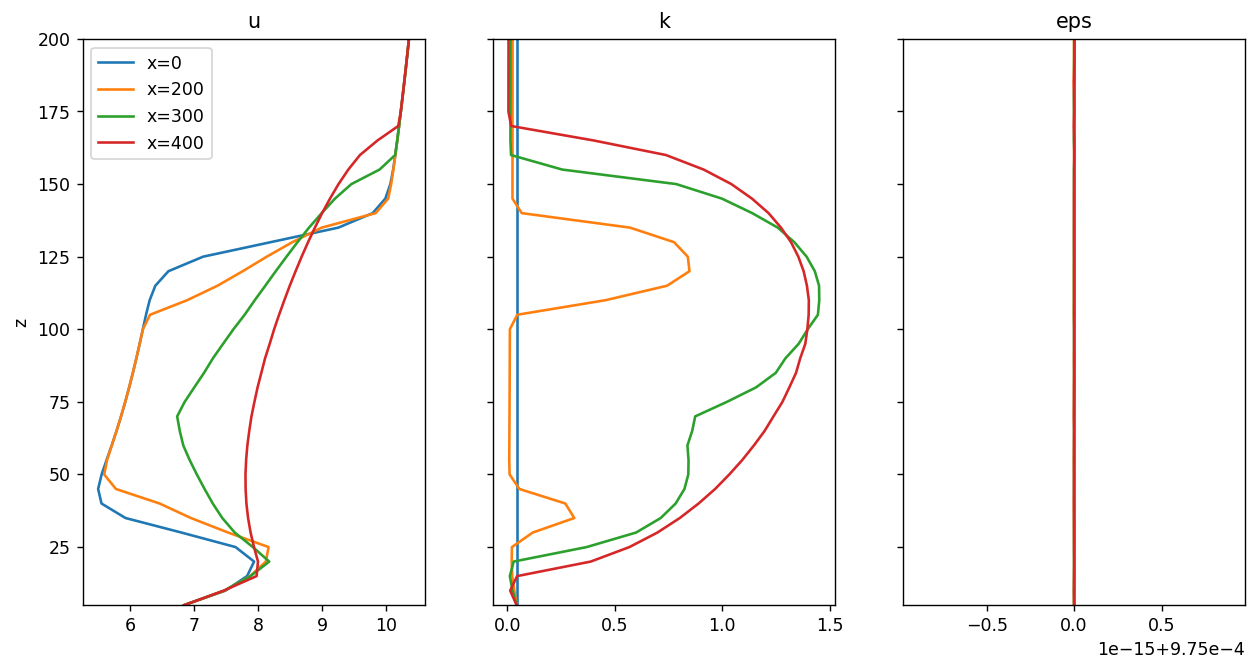

In [14]:
plotvars=['u', 'k', 'eps']
islice = Ny//2
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    #axs[iv].plot(np.mean(phi[v][0,:,:], axis=0), zvec,)
    #axs[iv].plot(np.mean(phi[v][-1,:,:], axis=0), zvec,)
    #axs[iv].plot(phi[v][0,islice,:], zvec,)
    #axs[iv].plot(phi[v][-1,islice,:], zvec,)    
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

Text(0, 0.5, 'z')

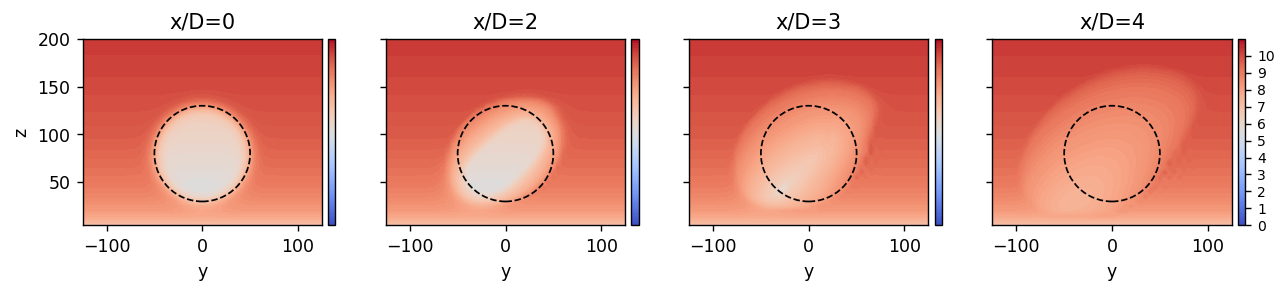

In [15]:
cbarticks=np.arange(0,11,1)

fig, axs = plt.subplots(1, len(xvecplot), figsize=(12,4), dpi=125, sharey=True)
for ix, x in enumerate(xvecplot):
    ixRANS = find_nearest(xvec, x)
    c=axs[ix].contourf(ym, zm, phi['u'][ixRANS,:,:], levels=np.linspace(0,11,91), cmap='coolwarm')
    axs[ix].set_aspect('equal')
    axs[ix].set_title('x/D=%.0f'%(0.5*x/turbR))
    axs[ix].set_xlabel('y')
    rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', fill=False)
    axs[ix].add_patch(rotorcirc)
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    if ix < len(xvecplot)-1:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
    else:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax,ticks = matplotlib.ticker.FixedLocator(cbarticks))
        cbar.ax.tick_params(labelsize=8)
        
axs[0].set_ylabel('z')